In [11]:
# Cell 1: unzip the data folder with original statements

!unzip data.zip

Archive:  data.zip
replace data/raw/audio/christian_approve.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [12]:
# Cell 2: Import Dependencies

import warnings
from pathlib import Path
import re
import IPython.display as ipd

import joblib
import librosa
import librosa.display as librosa_display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                           confusion_matrix, f1_score, roc_auc_score, roc_curve)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (14, 5)})

print("Libraries installed")

Libraries installed


In [13]:
# Cell 3: Configuration
ROOT_DIR = Path.cwd()
RAW_AUDIO_DIR = ROOT_DIR / "data" / "raw" / "audio"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

TARGET_SR = 16000
RANDOM_STATE = 42

AUTHORIZED_USERS = ["hikma", "silver", "emmanuel", "christian"]

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Configuration Loaded")
print(f"Authorized Users: {AUTHORIZED_USERS}")

✅ Configuration Loaded
Authorized Users: ['hikma', 'silver', 'emmanuel', 'christian']


In [14]:
# Cell 4: Load files and create 3 augmentations
ORIGINAL_PATTERN = re.compile(r"^(?P<customer_id>[a-z]+)_(?P<phrase>approve|confirm)\.wav$")

def load_audio(path: Path):
    y, _ = librosa.load(path, sr=TARGET_SR, mono=True)
    return y.astype(np.float32)

def save_audio(y, output_path: Path):
    output_path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(output_path, y, TARGET_SR)

def augment_pitch_shift(y, steps=2):
    return librosa.effects.pitch_shift(y=y, sr=TARGET_SR, n_steps=steps)

def augment_add_noise(y, scale=0.006):
    rng = np.random.default_rng(RANDOM_STATE)
    noise = rng.normal(0.0, scale, len(y)).astype(np.float32)
    return y + noise

def augment_time_stretch(y, rate=1.25):
    return librosa.effects.time_stretch(y=y, rate=rate)

audio_inventory = []
original_files = [p for p in RAW_AUDIO_DIR.glob("*.wav") if ORIGINAL_PATTERN.match(p.name)]

print(f"Found {len(original_files)} original files")

for path in original_files:
    match = ORIGINAL_PATTERN.match(path.name)
    customer_id = match.group("customer_id")
    phrase = match.group("phrase")
    y = load_audio(path)

    pitch_path = RAW_AUDIO_DIR / f"{path.stem}_pitch.wav"
    noise_path = RAW_AUDIO_DIR / f"{path.stem}_noise.wav"
    stretch_path = RAW_AUDIO_DIR / f"{path.stem}_stretch.wav"

    if not pitch_path.exists(): save_audio(augment_pitch_shift(y), pitch_path)
    if not noise_path.exists(): save_audio(augment_add_noise(y), noise_path)
    if not stretch_path.exists(): save_audio(augment_time_stretch(y), stretch_path)

    audio_inventory.extend([
        {"customer_id": customer_id, "phrase": phrase, "source_file": path.name, "sample_type": "original"},
        {"customer_id": customer_id, "phrase": phrase, "source_file": pitch_path.name, "sample_type": "pitch_shift"},
        {"customer_id": customer_id, "phrase": phrase, "source_file": noise_path.name, "sample_type": "add_noise"},
        {"customer_id": customer_id, "phrase": phrase, "source_file": stretch_path.name, "sample_type": "time_stretch"},
    ])

audio_df = pd.DataFrame(audio_inventory)
print(f"✅ Total samples: {len(audio_df)}")

Found 8 original files
✅ Total samples: 32


In [15]:
# Cell 5: Create Synthetic Unauthorized Samples
print("=== Creating Unauthorized Samples ===")

unauthorized_samples = []
for _, row in audio_df.sample(frac=0.35, random_state=RANDOM_STATE).iterrows():
    if row["customer_id"] in AUTHORIZED_USERS:
        y = load_audio(RAW_AUDIO_DIR / row["source_file"])
        y_unauth = y * 0.93 + np.random.normal(0, 0.018, len(y)).astype(np.float32)

        unauth_filename = f"unknown_{row['source_file']}"
        unauth_path = RAW_AUDIO_DIR / unauth_filename

        if not unauth_path.exists():
            save_audio(y_unauth, unauth_path)

        unauthorized_samples.append({
            "customer_id": "unknown",
            "phrase": row["phrase"],
            "source_file": unauth_filename,
            "sample_type": row["sample_type"] + "_unknown"
        })

audio_df = pd.concat([audio_df, pd.DataFrame(unauthorized_samples)], ignore_index=True)
print(f"✅ Added {len(unauthorized_samples)} unauthorized samples")

=== Creating Unauthorized Samples ===
✅ Added 11 unauthorized samples



📊 Visualizing + Playing: hikma - confirm (original)


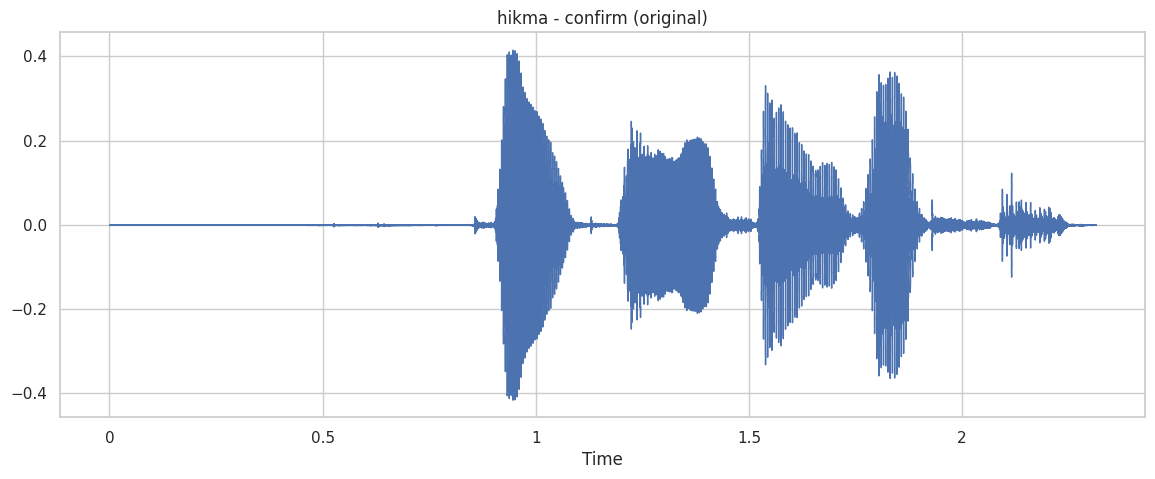

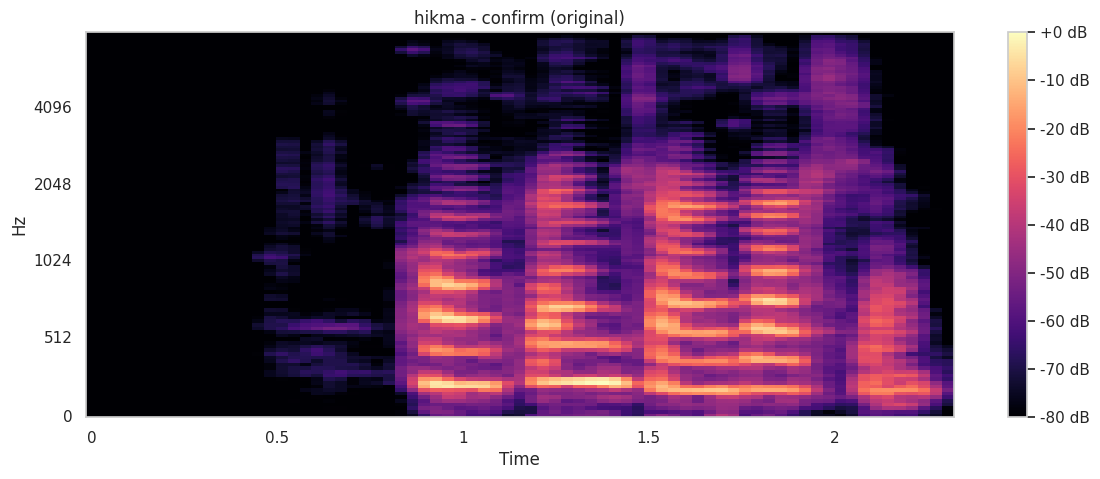


📊 Visualizing + Playing: hikma - confirm (pitch_shift)


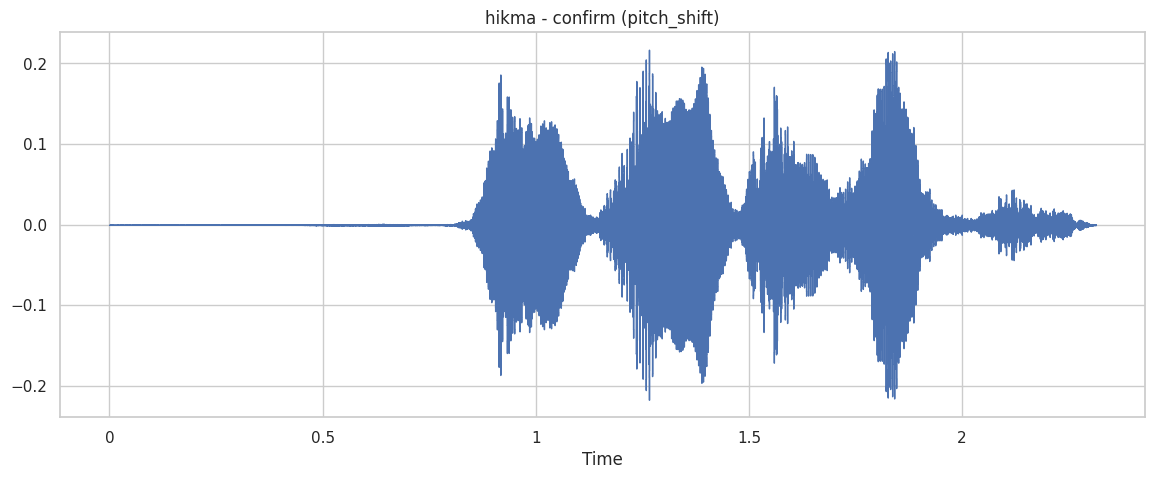

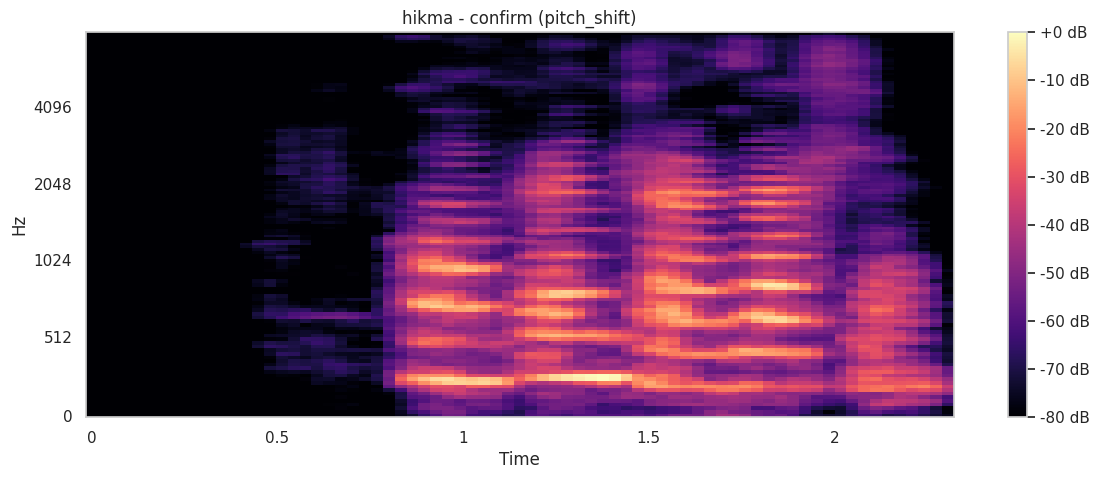


📊 Visualizing + Playing: hikma - confirm (add_noise)


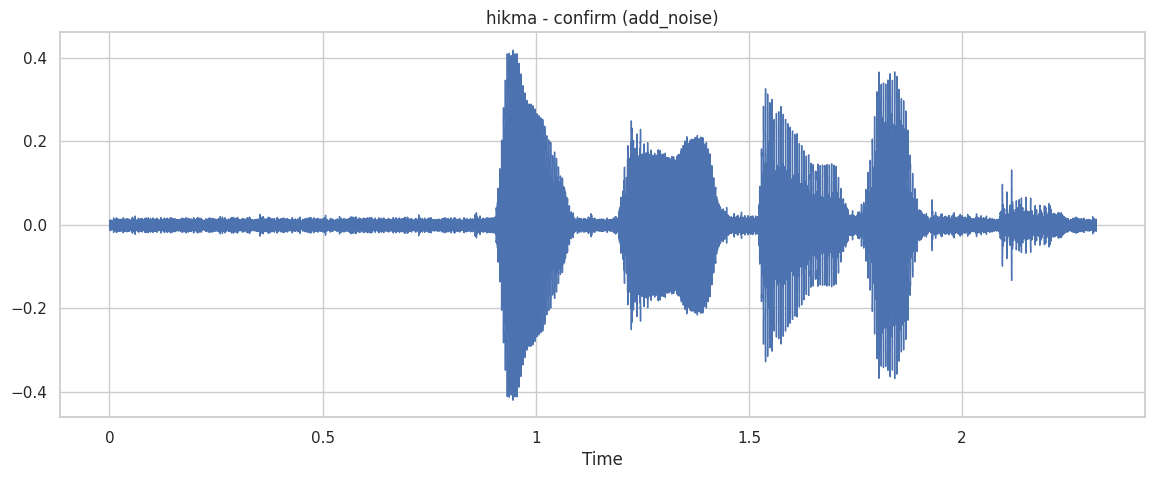

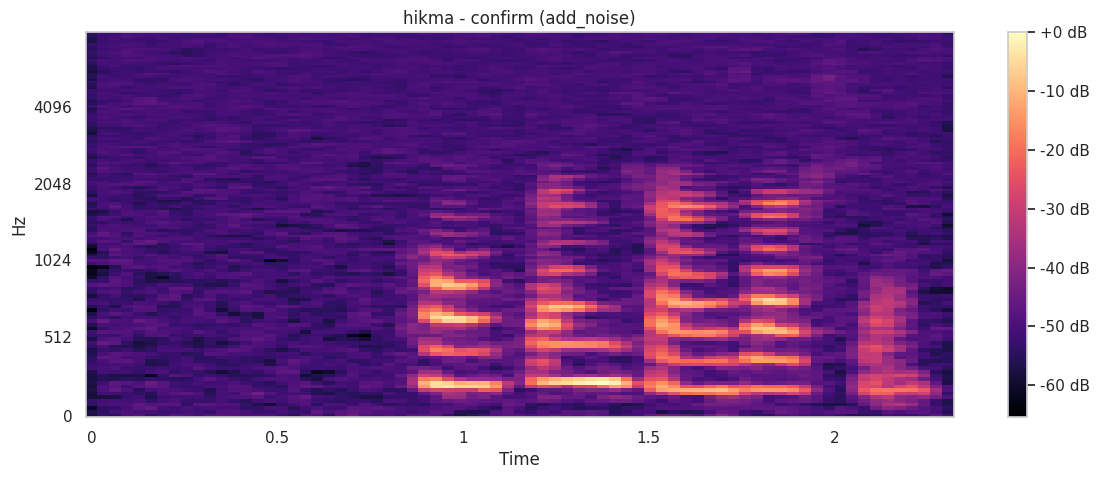


📊 Visualizing + Playing: hikma - confirm (time_stretch)


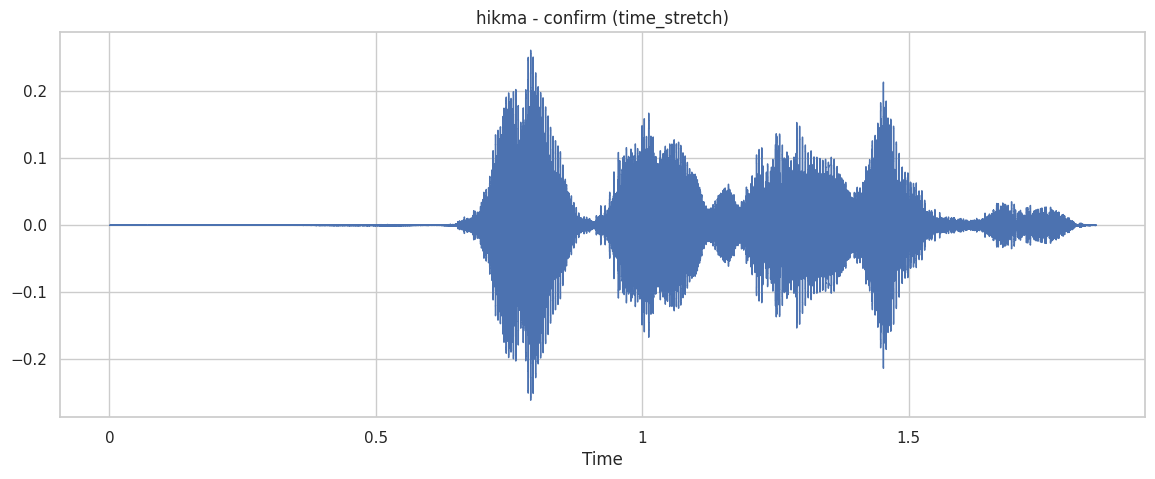

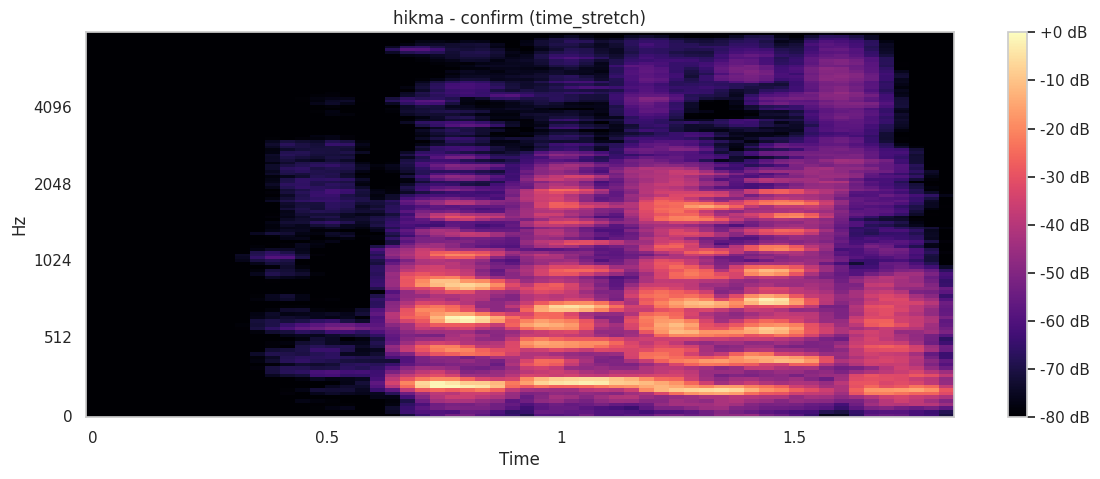


📊 Visualizing + Playing: silver - approve (original)


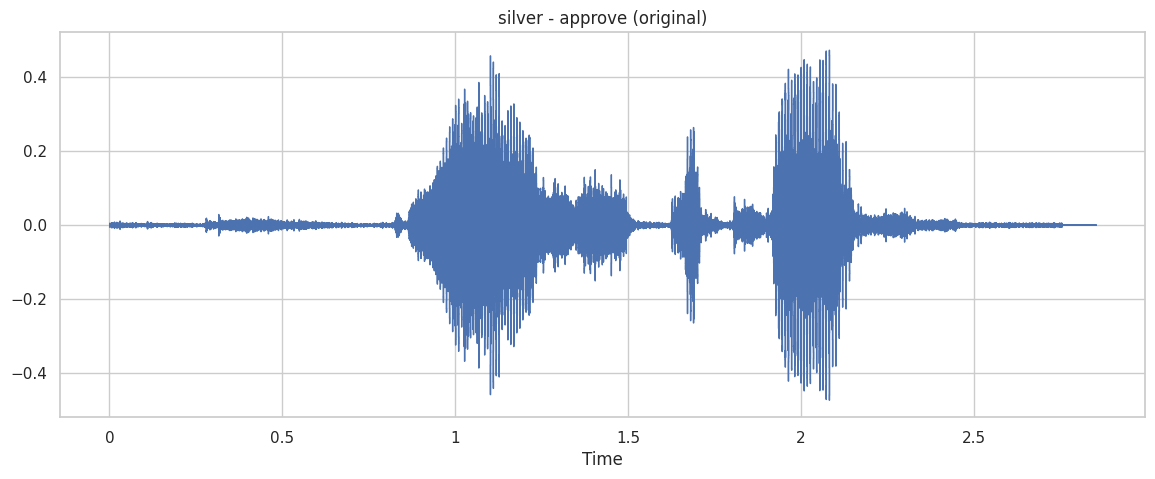

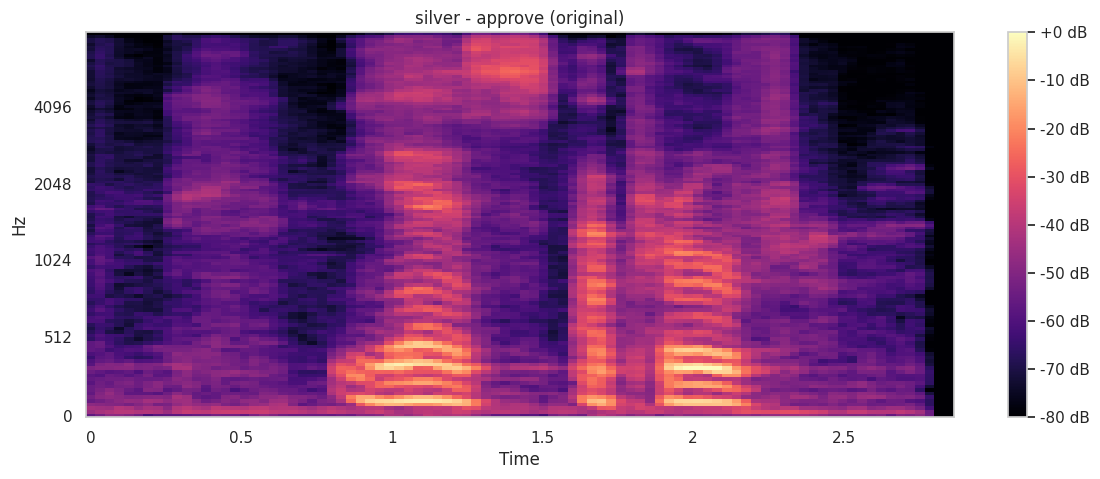


📊 Visualizing + Playing: silver - approve (pitch_shift)


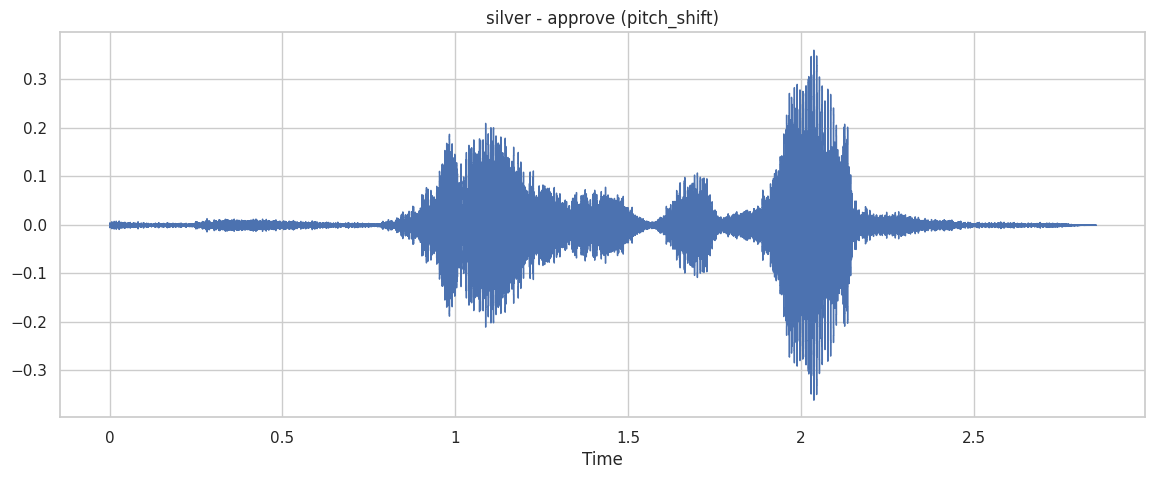

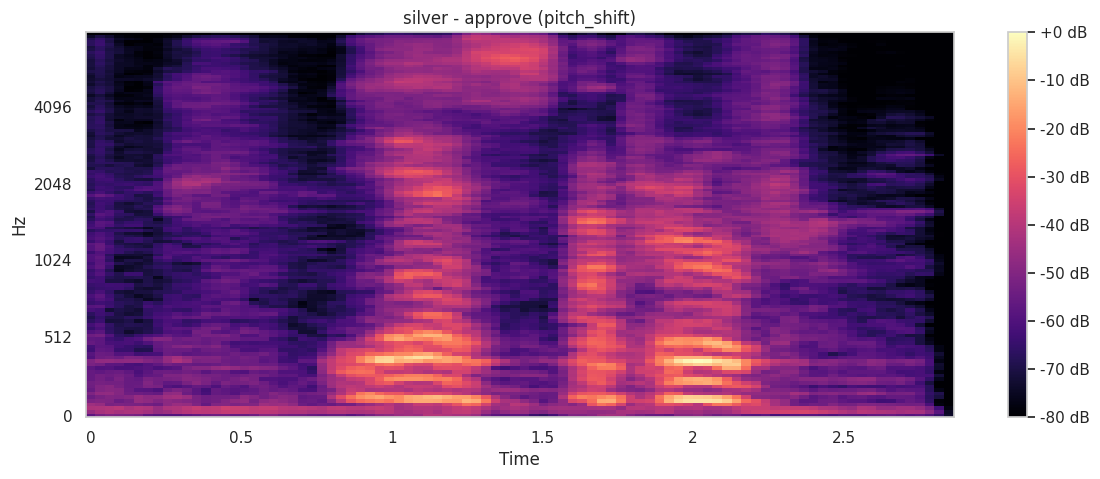


📊 Visualizing + Playing: silver - approve (add_noise)


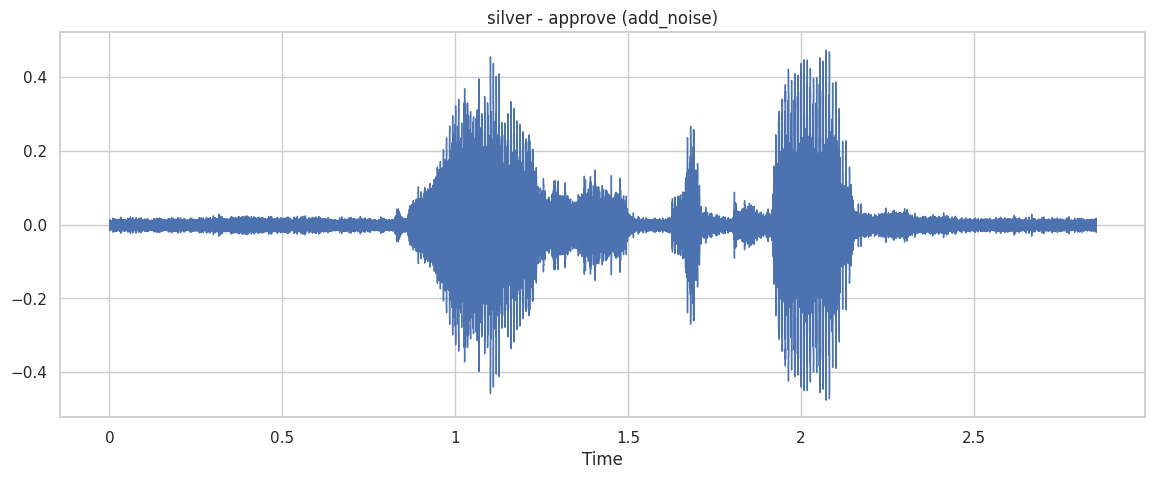

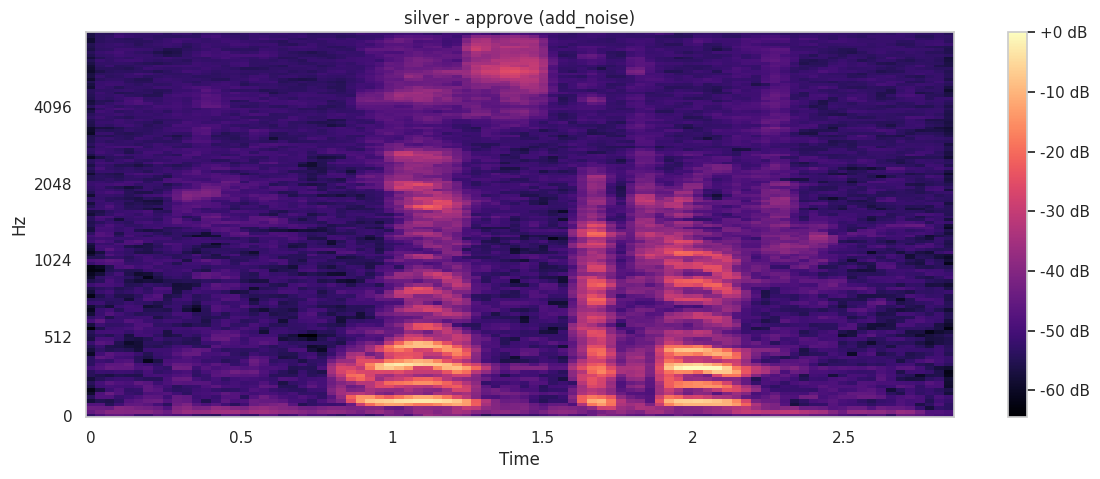


📊 Visualizing + Playing: silver - approve (time_stretch)


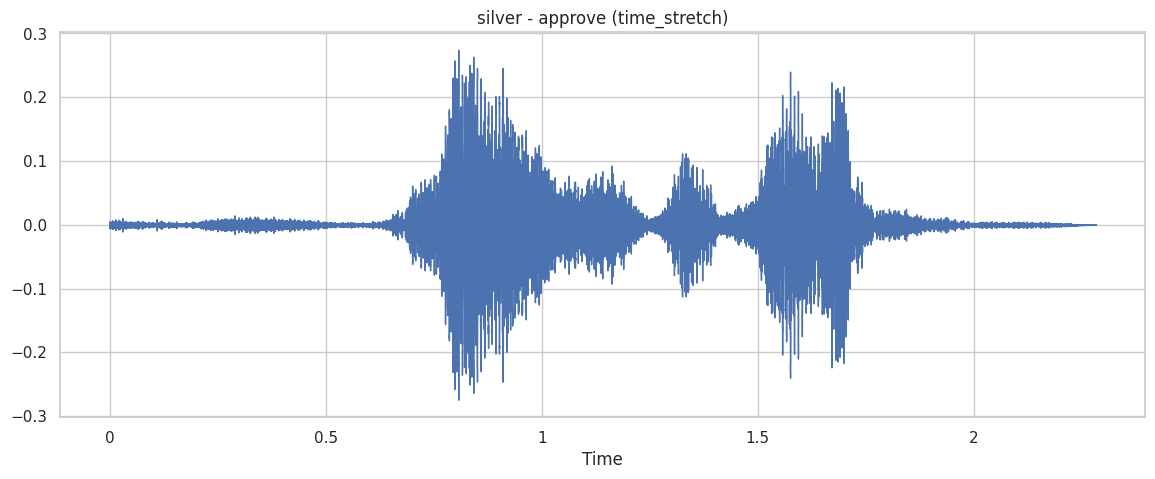

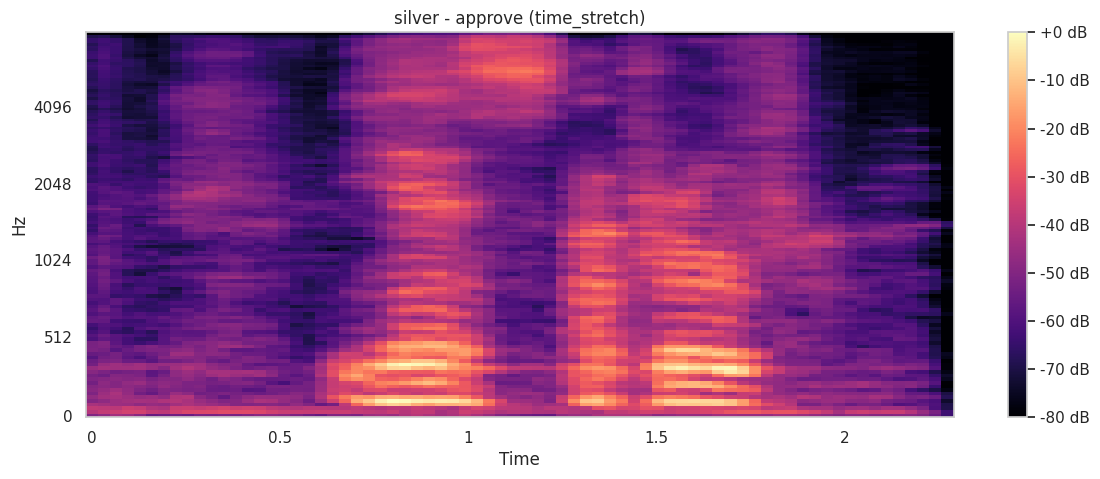


✅ audio_features.csv saved | Shape: (43, 36)


In [16]:
# Cell 6: Feature Extraction + Visualizations + Audio Samples Playback
def extract_features(y):
    features = {}
    features["zero_crossing_rate_mean"] = float(np.mean(librosa.feature.zero_crossing_rate(y)[0]))
    features["rms_energy_mean"] = float(np.mean(librosa.feature.rms(y=y)[0]))
    features["spectral_centroid_mean"] = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=TARGET_SR)[0]))
    features["spectral_rolloff_mean"] = float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=TARGET_SR)[0]))

    mfcc = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=13)
    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = float(np.mean(mfcc[i]))
        features[f"mfcc_{i+1}_std"] = float(np.std(mfcc[i]))
    features["duration_seconds"] = float(librosa.get_duration(y=y, sr=TARGET_SR))
    return features

def plot_waveform(y, title):
    plt.figure()
    librosa_display.waveshow(y, sr=TARGET_SR)
    plt.title(title)
    plt.show()

def plot_spectrogram(y, title):
    plt.figure()
    mel_spec = librosa.feature.melspectrogram(y=y, sr=TARGET_SR, n_mels=128)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa_display.specshow(mel_db, sr=TARGET_SR, x_axis='time', y_axis='mel', cmap='magma')
    plt.title(title)
    plt.colorbar(format='%+2.0f dB')
    plt.show()

# Extract features
feature_rows = []
for _, row in audio_df.iterrows():
    audio_path = RAW_AUDIO_DIR / row["source_file"]
    y = load_audio(audio_path)

    if len(feature_rows) < 8:
        title = f"{row['customer_id']} - {row['phrase']} ({row['sample_type']})"
        print(f"\n📊 Visualizing + Playing: {title}")
        plot_waveform(y, title)
        plot_spectrogram(y, title)
        display(ipd.Audio(audio_path))   # ← Audio Playback

    feats = extract_features(y)
    feature_rows.append({
        "customer_id": row["customer_id"],
        "phrase": row["phrase"],
        "sample_type": row["sample_type"],
        "file_name": row["source_file"],
        "is_authorized": int(row["customer_id"] in AUTHORIZED_USERS),
        **feats
    })

features_df = pd.DataFrame(feature_rows)
features_df.to_csv(PROCESSED_DIR / "audio_features.csv", index=False)
print(f"\n✅ audio_features.csv saved | Shape: {features_df.shape}")

In [17]:
# Cell 7: Train Model
print("=== Training Model ===")
features_df["is_authorized"] = features_df["customer_id"].isin(AUTHORIZED_USERS).astype(int)

train_df = features_df[features_df["phrase"] == "approve"].copy()
test_df = features_df[features_df["phrase"] == "confirm"].copy()

feature_cols = [col for col in features_df.columns if col not in ["customer_id", "phrase", "sample_type", "file_name", "is_authorized"]]

X_train = train_df[feature_cols]
y_train = train_df["is_authorized"]
X_test = test_df[feature_cols]
y_test = test_df["is_authorized"]

model = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, class_weight="balanced")
model.fit(X_train, y_train)

print("Model trained successfully")

=== Training Model ===
Model trained successfully


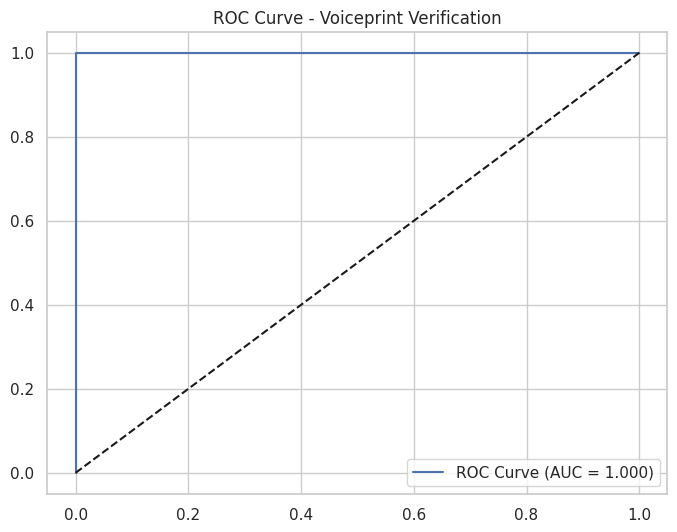

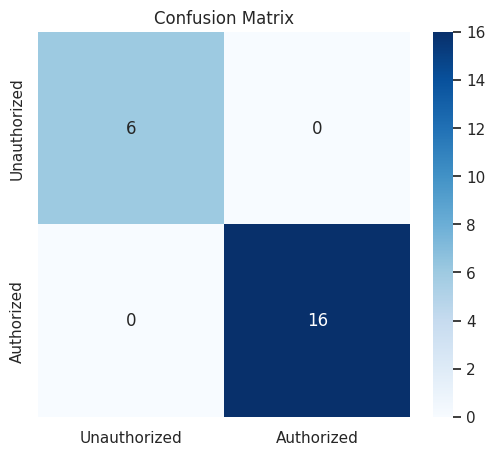

In [18]:
# Cell 8: ROC Curve + Confusion Matrix
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Voiceprint Verification')
plt.legend()
plt.grid(True)
plt.show()

cm = confusion_matrix(y_test, model.predict(X_test))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unauthorized', 'Authorized'],
            yticklabels=['Unauthorized', 'Authorized'])
plt.title('Confusion Matrix')
plt.show()

In [19]:
# Cell 9: Final Authentication Demo with Audio Playback
print("=== FINAL AUTHENTICATION DEMO ===\n")

def predict_voice(audio_path):
    y = load_audio(audio_path)
    feats = extract_features(y)
    X = pd.DataFrame([feats])[feature_cols]

    prob = model.predict_proba(X)[0][1]
    customer = audio_path.stem.split('_')[0]

    print(f"Testing: {audio_path.name} ({customer})")
    print(f"Authorized Probability: {prob:.3f}")
    display(ipd.Audio(audio_path))

    if prob > 0.85:
        print("✅ ACCESS GRANTED - Authorized Group Member")
    else:
        print("❌ ACCESS DENIED - Unknown User")
    print("-" * 80)

# Test authorized
for member in AUTHORIZED_USERS:
    file = next(RAW_AUDIO_DIR.glob(f"{member}_approve*.wav"), None)
    if file:
        predict_voice(file)

# Test unauthorized
print("\n--- Unauthorized Test ---")
unauth_file = next((f for f in RAW_AUDIO_DIR.glob("*.wav") if "unknown" in f.name), None)
if unauth_file:
    predict_voice(unauth_file)

=== FINAL AUTHENTICATION DEMO ===

Testing: hikma_approve_noise.wav (hikma)
Authorized Probability: 0.990


✅ ACCESS GRANTED - Authorized Group Member
--------------------------------------------------------------------------------
Testing: silver_approve_noise.wav (silver)
Authorized Probability: 0.973


✅ ACCESS GRANTED - Authorized Group Member
--------------------------------------------------------------------------------
Testing: emmanuel_approve_stretch.wav (emmanuel)
Authorized Probability: 1.000


✅ ACCESS GRANTED - Authorized Group Member
--------------------------------------------------------------------------------
Testing: christian_approve_noise.wav (christian)
Authorized Probability: 0.860


✅ ACCESS GRANTED - Authorized Group Member
--------------------------------------------------------------------------------

--- Unauthorized Test ---
Testing: unknown_emmanuel_confirm_noise.wav (unknown)
Authorized Probability: 0.015


❌ ACCESS DENIED - Unknown User
--------------------------------------------------------------------------------


In [20]:
print("=== Saving Model for System Integration ===")

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_bundle = {
    "model": model,
    "feature_columns": feature_cols,
    "authorized_users": AUTHORIZED_USERS,
    "target_sr": TARGET_SR,
    "threshold": 0.95,
    "metrics": {
        "accuracy": float(acc),
        "f1_score": float(f1),
        "auc": float(auc) if 'auc' in locals() else None
    }
}

model_path = PROCESSED_DIR / "voice_model.pkl"
joblib.dump(model_bundle, model_path)

print(f"✅ Model successfully saved to: {model_path}")
print(f"File size: {model_path.stat().st_size / 1024:.1f} KB")

=== Saving Model for System Integration ===
✅ Model successfully saved to: /content/data/processed/voice_model.pkl
File size: 277.6 KB
